# **Exploratory Data Analysis (EDA) – Shopping Trends Dataset**

## **Q1: Dataset Cleaning**

### Q1.a: Display the first 10 rows of shopping trends
**Insight:** Gives a quick look at the dataset structure, columns, and sample values.


In [ ]:
from IPython.display import display, Markdown
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('shopping_trends_updated.csv')
display(df.head(10).style.set_table_attributes('style="width:100%;border:1px solid black;"'))


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.100000,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.100000,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.100000,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.500000,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.700000,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.900000,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.200000,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.200000,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.600000,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.800000,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


### Q1.b: Checking if there are any null values present in the dataset or not?
**Insight:** Identifies missing data in each column. This helps plan data cleaning (`fillna`/`dropna`) before analysis.

In [7]:
display(Markdown("### Display the count of missing values in each column"))
display(df.isnull().sum())

### Display the count of missing values in each column

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

### Q1.c: Checking if there are any duplicate values present in the dataset or not?
**Insight:** Shows the number of exact duplicate rows. Removing duplicates ensures accuracy in analysis.


In [8]:
display(df.duplicated().sum())


np.int64(0)

### Q1.d: Display the information of the total entries, columns, and data types
**Insight:** Provides a summary of entries, columns, data types, and memory usage. Helps plan preprocessing steps.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## **Q2: Numerical Feature Analysis**

### Display the distributions of numerical features with mean and median

**Insight:**  
- Helps understand the central tendency and spread of numerical features like purchase amount, age, etc.  
- Histograms with KDE plots show the **distribution shape**, **skewness**, and **outliers**.  
- Vertical lines indicate **mean (dashed red)** and **median (solid green)** values, providing a clear view of the data’s central tendencies.  
- Useful for identifying features that may require **normalization or transformation** before further analysis.


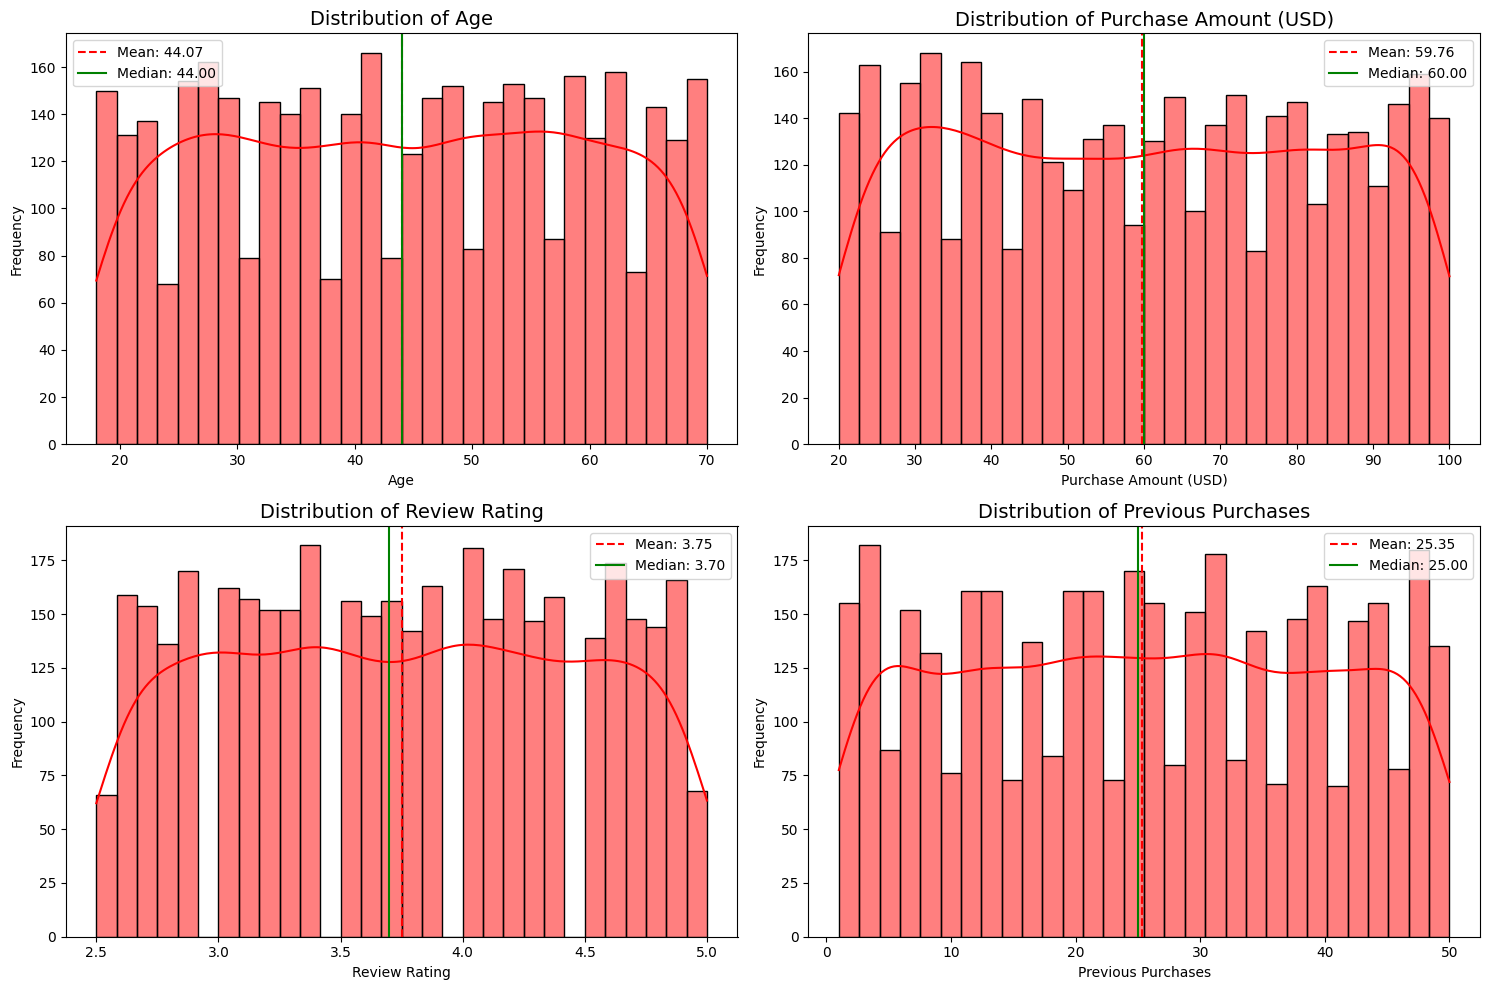

In [10]:
import numpy as np
numerical_features = df.drop('Customer ID', axis=1).select_dtypes(include=[np.number])
numerical_features.columns
numerical_features = df.drop('Customer ID', axis=1).select_dtypes(include=[np.number])
numerical_features.columns
def plot_distributions(data, columns, rows):

    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    # Create a figure with subplots
    fig, axes = plt.subplots(rows, columns, figsize=(15, 10))
    axes = axes.flatten()

    for i, column in enumerate(data.columns):
        ax = axes[i]

        sns.histplot(data[column], kde=True, ax=ax, color='red', bins=30)

        # Calculate mean and median
        mean_value = data[column].mean()
        median_value = data[column].median()

        # Add vertical lines for mean and median
        ax.axvline(mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f}')
        ax.axvline(median_value, color='green', linestyle='-', label=f'Median: {median_value:.2f}')
        ax.set_title(f'Distribution of {column}', fontsize=14)
        ax.set_xlabel(column)
        ax.set_ylabel('Frequency')

        # Add legend
        ax.legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()
plot_distributions(numerical_features, columns=2, rows=2)

## **Q3: Customer Demographics**

### Q3.a: Display the gender distribution in a pie chart

**Insight:**  
- Shows the proportion of male and female customers.  
- Pie chart slices represent the percentage of each gender, with one slice slightly exploded for emphasis.  
- Helps understand the composition of the customer base, which is useful for gender-targeted marketing strategies.

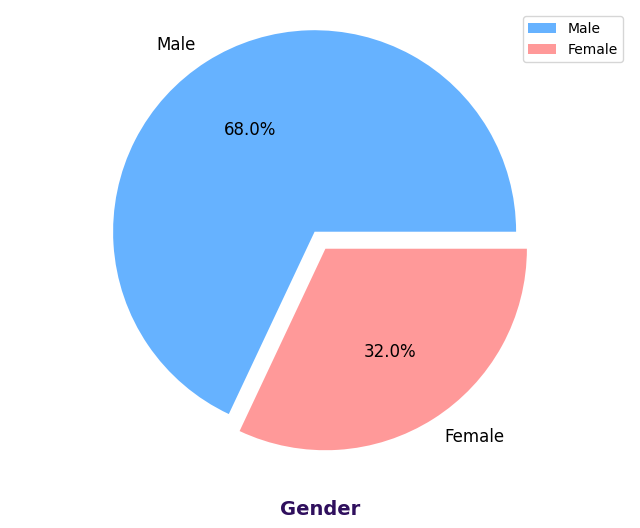

In [ ]:
# Define colors for the pie chart
colors = ['#66B2FF' , '#FF9999']  # Example colors for Male and Female

counts = df["Gender"].value_counts()
explode = (0, 0.1) 

# Plot pie chart
plt.figure(figsize=(8, 6))
counts.plot(
    kind='pie',
    fontsize=12,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%'
)
plt.ylabel('')  # Remove default y-label
plt.xlabel('Gender', weight="bold", color="#2F0F5D", fontsize=14, labelpad=20)
plt.axis('equal')  # Equal aspect ratio ensures pie chart is circular
plt.legend(labels=counts.index, loc="best")
plt.show()


### Q3.b: Display subscription status by gender in a stacked bar chart

**Insight:**  
- Displays how subscription behavior varies by gender.  
- Stacked bars allow comparison of subscription vs non-subscription counts within each gender.  
- Useful for identifying which gender segment is more likely to subscribe, aiding in targeted campaigns.


<Figure size 2000x600 with 0 Axes>

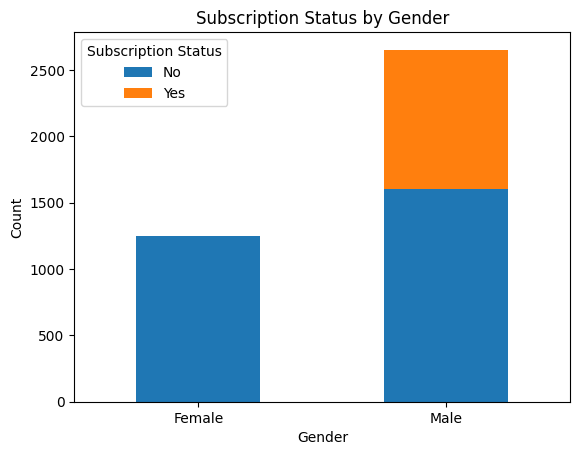

In [ ]:
subscription_gender_counts = df.groupby(['Gender', 'Subscription Status']).size().unstack()
plt.figure(figsize = (20, 6))
subscription_gender_counts.plot(kind='bar', stacked=True, rot = 0)
plt.title('Subscription Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## **Q4: Seasonal & Age Trends**

### Q4.a: Display the seasonal sales trend in a line chart

**Insight:**  
- Shows how average purchase amounts vary across different seasons.  
- Peaks and dips in the line chart reveal high and low sales periods, which can help in planning seasonal promotions.  
- Useful for identifying **seasonal trends** and optimizing marketing campaigns.


   Season  Purchase Amount (USD)
0    Fall              61.556923
1  Spring              58.737738
2  Summer              58.405236
3  Winter              60.357364


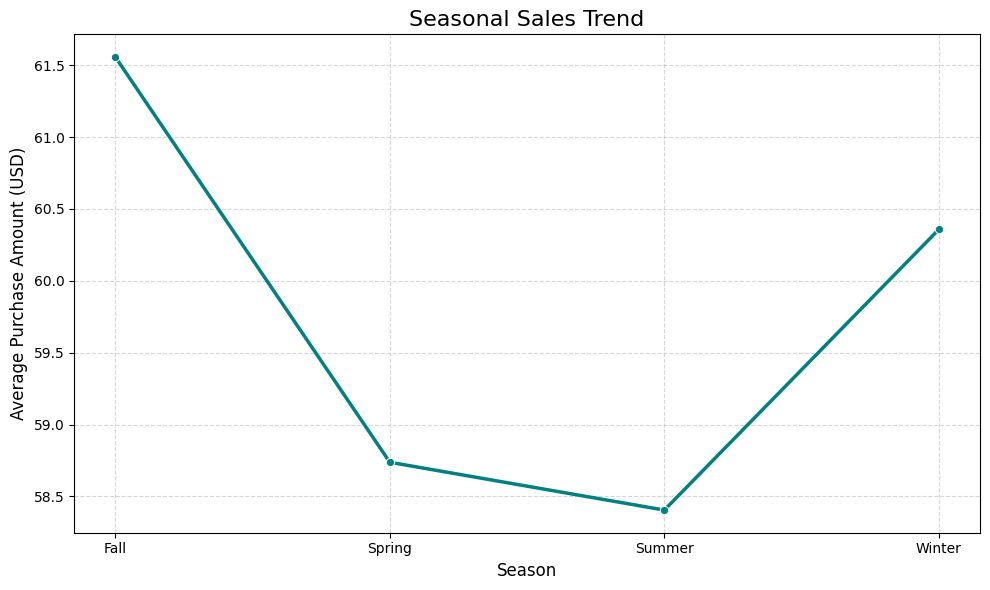

In [13]:
seasonal_average =df.groupby("Season")["Purchase Amount (USD)"].mean().reset_index()
print(seasonal_average)

plt.figure(figsize=(10, 6))
sns.lineplot(data=seasonal_average, x="Season", y="Purchase Amount (USD)", marker="o", linewidth=2.5, color="teal")


plt.title("Seasonal Sales Trend", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Purchase Amount (USD)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Q4.b: Display the average purchase amount by age in a line chart

**Insight:**  
- Displays spending patterns across different age groups.  
- Helps identify which age segments contribute most to revenue.  
- Useful for **age-targeted promotions** and personalized marketing strategies.


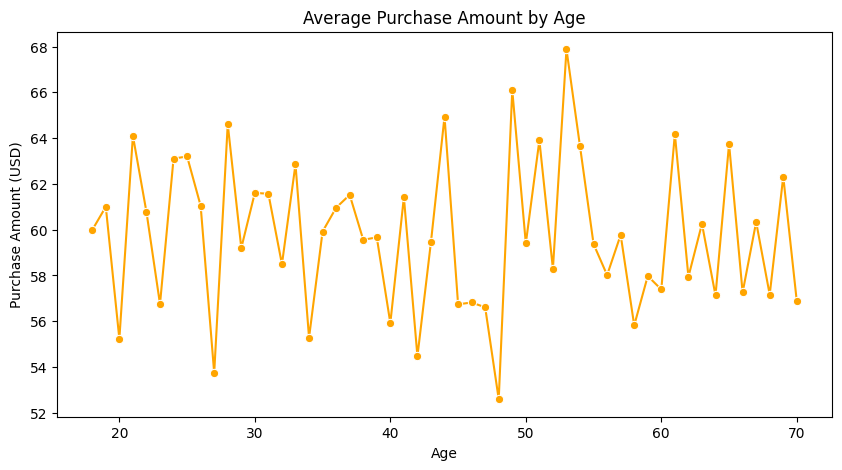

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Age", y="Purchase Amount (USD)", ci=None, marker="o", color="orange")
plt.title("Average Purchase Amount by Age")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.show()

## **Q5: Purchase Amount Distribution**

### Display the purchase amount distribution by season in a KDE plot

**Insight:**  
- Shows the distribution of purchase amounts for each season using Kernel Density Estimation (KDE).  
- Helps identify **seasonal peaks**, **spending patterns**, and potential high-value transactions.  
- Useful for understanding how customer spending varies across different times of the year, informing **seasonal marketing strategies**.


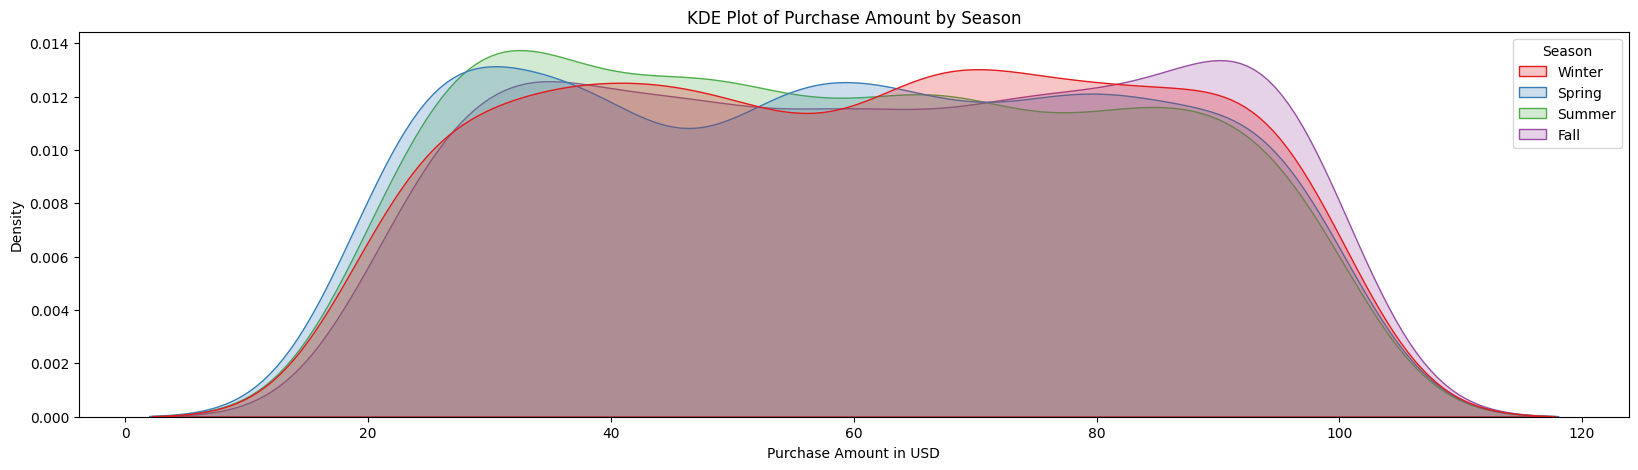

In [15]:
plt.figure(figsize=(20, 5))
sns.kdeplot(data = df, x = 'Purchase Amount (USD)', hue = 'Season', common_norm = False, fill = True, palette = 'Set1')
plt.title('KDE Plot of Purchase Amount by Season')
plt.xlabel('Purchase Amount in USD')
plt.show()

## **Q6: Payment Method Analysis**

### Display the payment method distribution in a pie chart

**Insight:**  
- Illustrates the proportion of each payment method used by customers.  
- Highlights the most preferred payment options (e.g., credit/debit card, digital wallets).  
- Useful for understanding customer **payment preferences** and optimizing payment channels for convenience and efficiency.


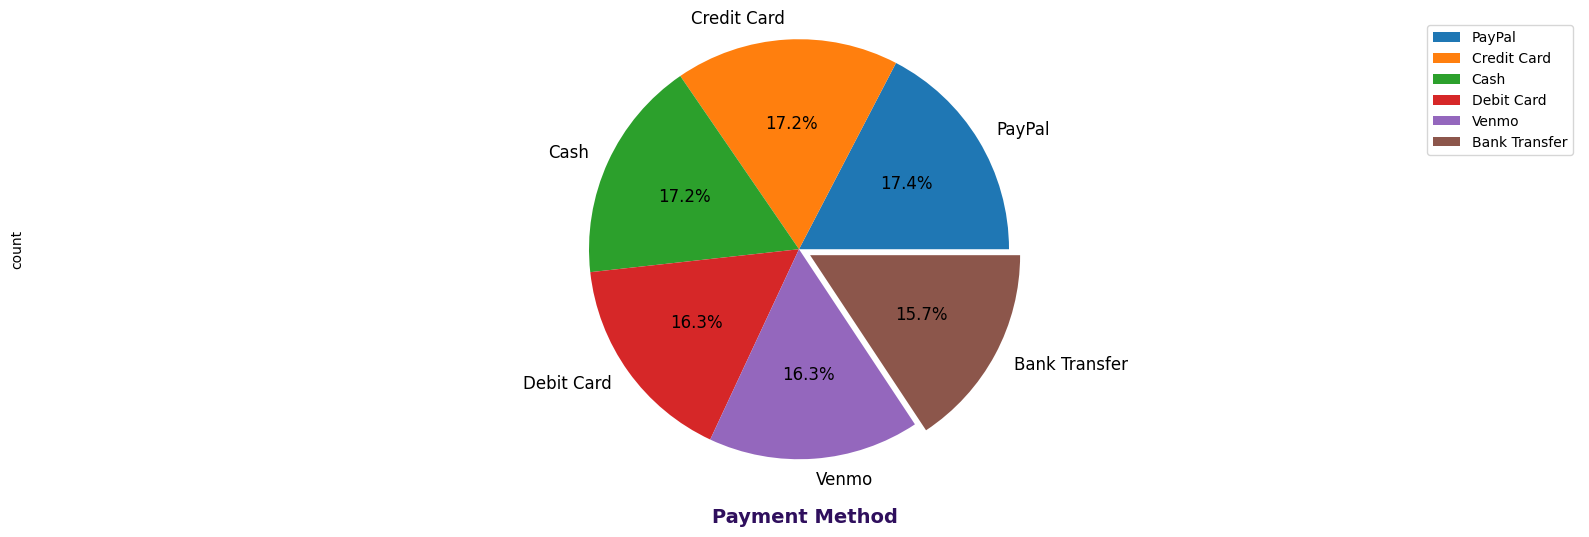

In [16]:
plt.figure(figsize=(20, 6))

counts = df["Payment Method"].value_counts()
explode = (0, 0, 0, 0, 0, 0.06)

# Generating distinct colors using seaborn color palette
colors = sns.color_palette('tab10', n_colors=len(counts))

counts.plot(kind='pie', fontsize=12, colors=colors, explode=explode, autopct='%1.1f%%')
plt.xlabel('Payment Method', weight="bold", color="#2F0F5D", fontsize=14, labelpad=20)
plt.axis('equal')
plt.legend(labels=counts.index, loc="best")
plt.show()


## **Q7: Purchase Patterns by Demographics**

### Q7.a: Display the age group distribution by payment method in a bar chart

**Insight:**  
- Shows the percentage of customers in each age group using different payment methods.  
- Helps identify **preferred payment methods** across age segments.  
- Useful for targeting **age-specific payment promotions** or optimizing payment options for different customer groups.



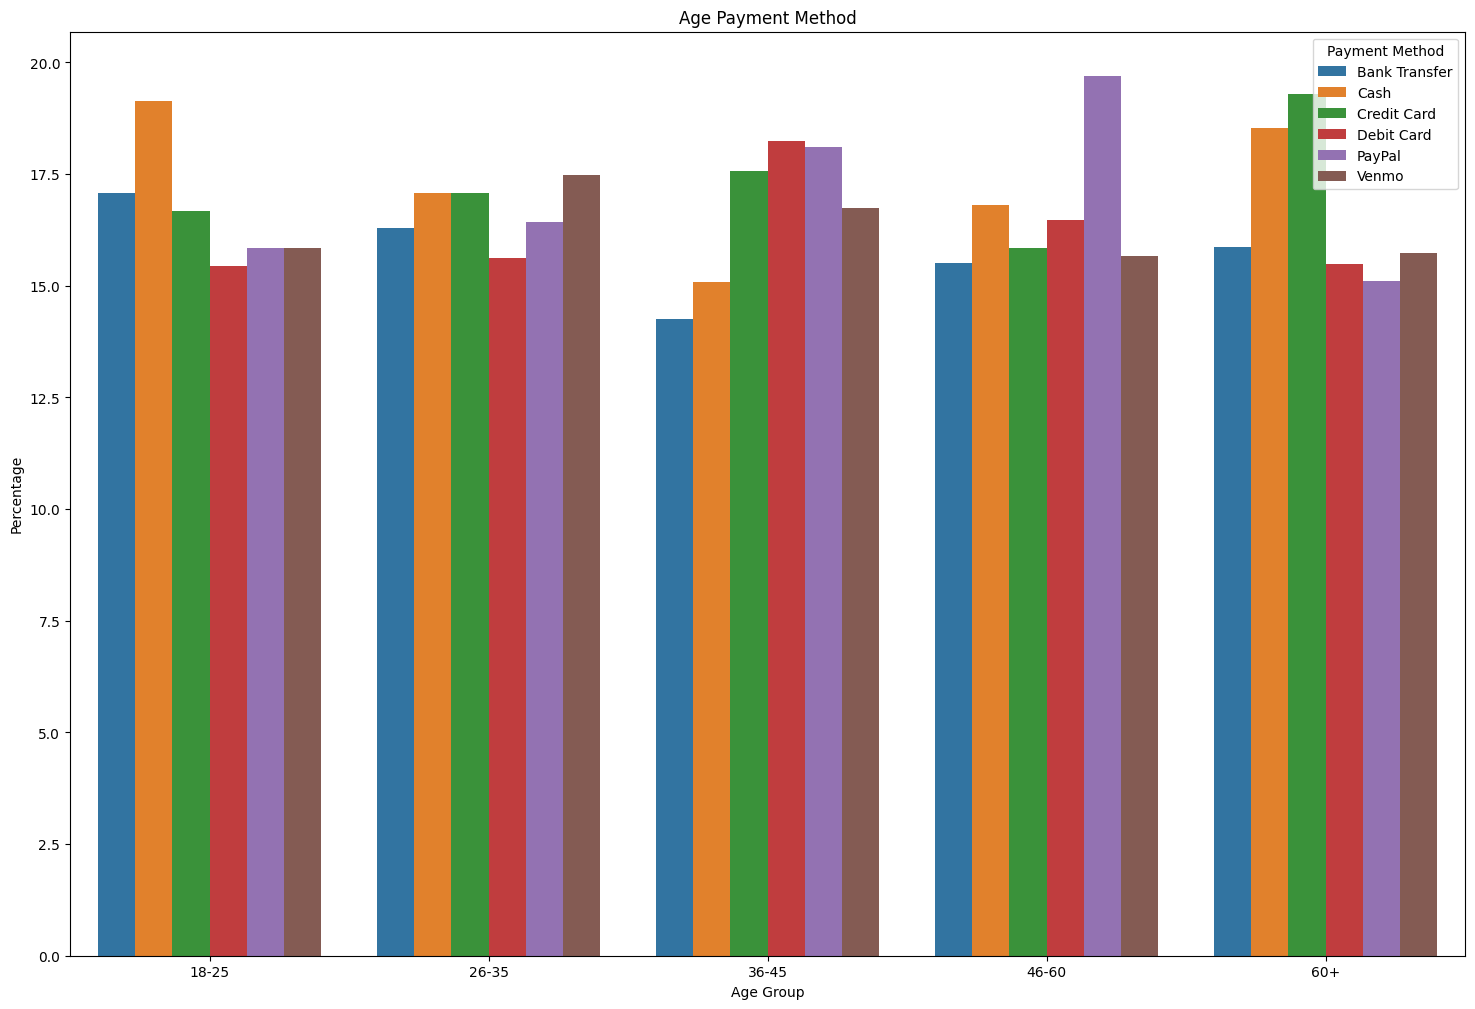

In [17]:
bins = [ 18, 25, 35, 45, 60, 100]  
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_payment = df.groupby('Payment Method')['Age Group'].value_counts().reset_index()
age_payment['percentage'] = age_payment['count'] / age_payment.groupby('Age Group')['count'].transform('sum') * 100
age_payment
plt.figure(figsize=(18,12))
sns.barplot(data=age_payment, x='Age Group', y='percentage', hue='Payment Method')
plt.title('Age Payment Method')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.show()


### Q7.b: Display the purchase amount by season and payment method in a bar chart

**Insight:**  
- Illustrates how purchase amounts vary across seasons for different payment methods.  
- Helps identify which payment methods are associated with higher spending during specific seasons.  
- Useful for **seasonal marketing strategies** and optimizing payment options to boost sales.


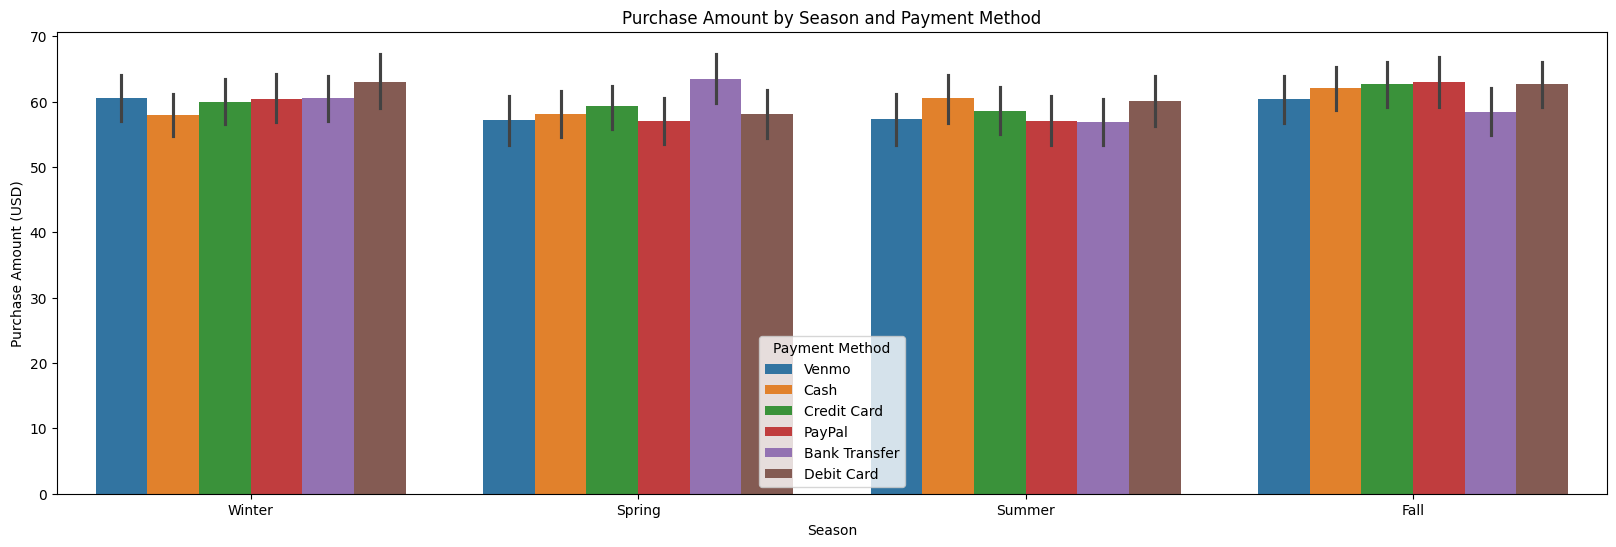

In [18]:
plt.figure(figsize=(20, 6))
sns.barplot(x='Season', y='Purchase Amount (USD)', hue='Payment Method', data=df)
plt.title('Purchase Amount by Season and Payment Method')
plt.xlabel('Season')
plt.ylabel('Purchase Amount (USD)')
plt.xticks(rotation = 0)
plt.show()

## **Q8: Item-Level Analysis**

### Q8.a: Display the distribution of items purchased in a bar chart

**Insight:**  
- Shows the overall popularity of items purchased across the dataset.  
- Helps identify **most frequently purchased items**, informing inventory and sales strategies.

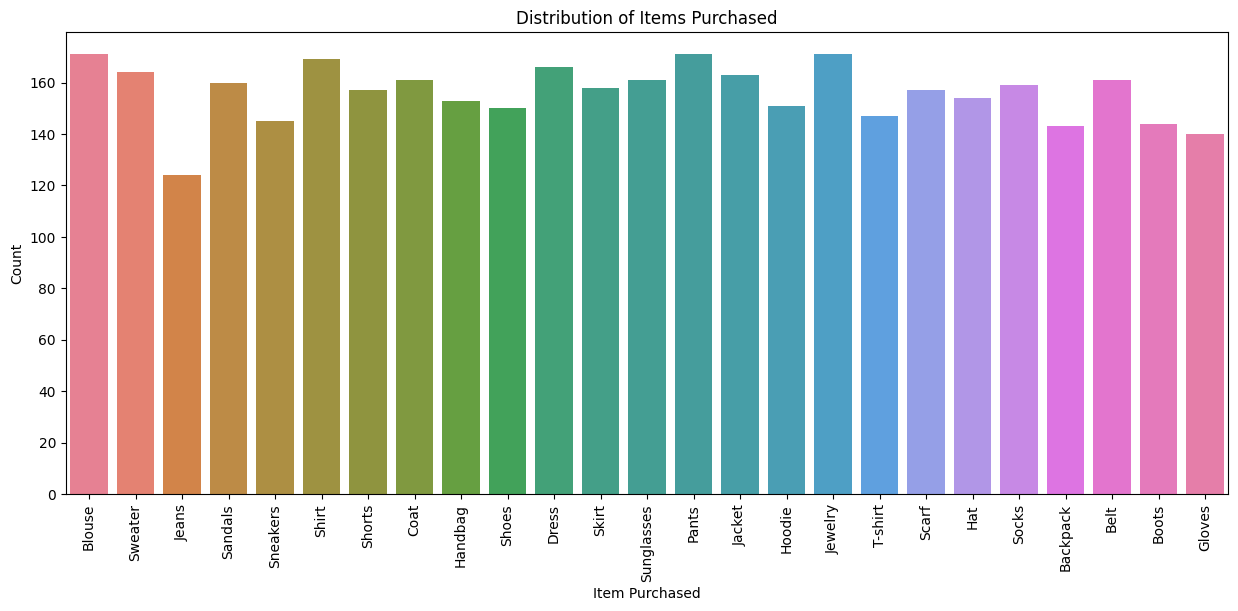

In [ ]:
plt.figure(figsize=(15,6))
sns.countplot(data=df, x='Item Purchased', hue='Item Purchased', dodge=False) 
plt.xlabel("Item Purchased")
plt.ylabel("Count")
plt.title("Distribution of Items Purchased")
plt.xticks(rotation=90)
plt.legend([],[], frameon=False)
plt.show()

### Q8.b: Display the top items in each category in separate bar charts

**Insight:**  
- Highlights the **best-selling products** in each category (e.g., Accessories, Clothing, Footwear, Outerwear).  
- Useful for **targeted marketing**, stock optimization, and category-specific promotions.


### Q8: Display the top items in Accessories category in a bar chart

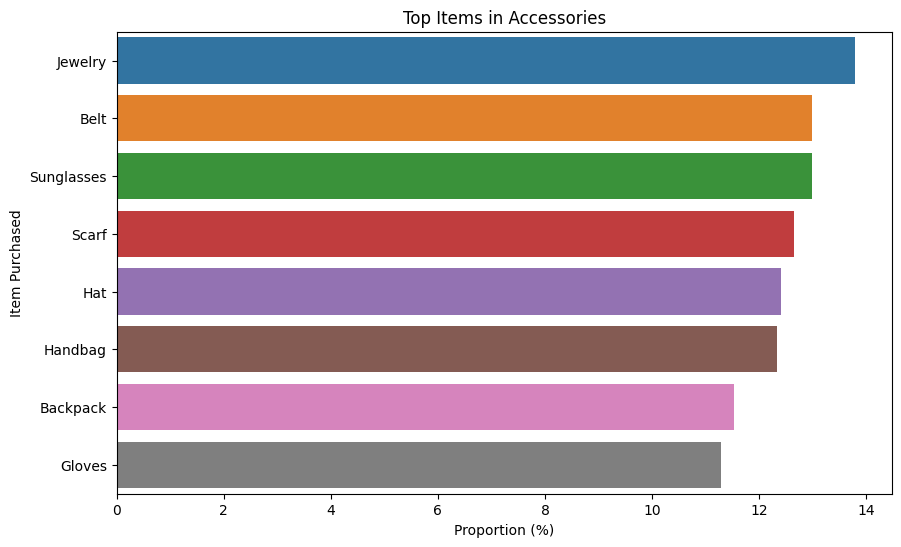

### Q8: Display the top items in Clothing category in a bar chart

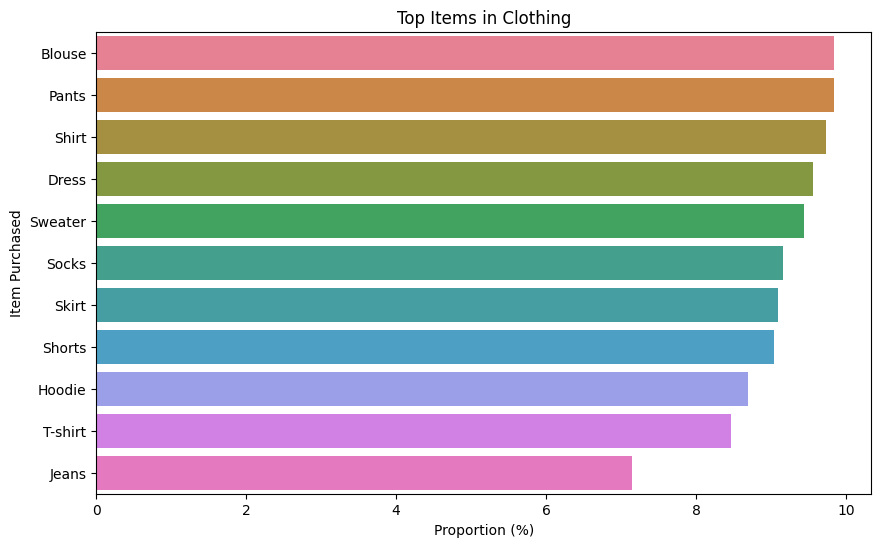

### Q8: Display the top items in Footwear category in a bar chart

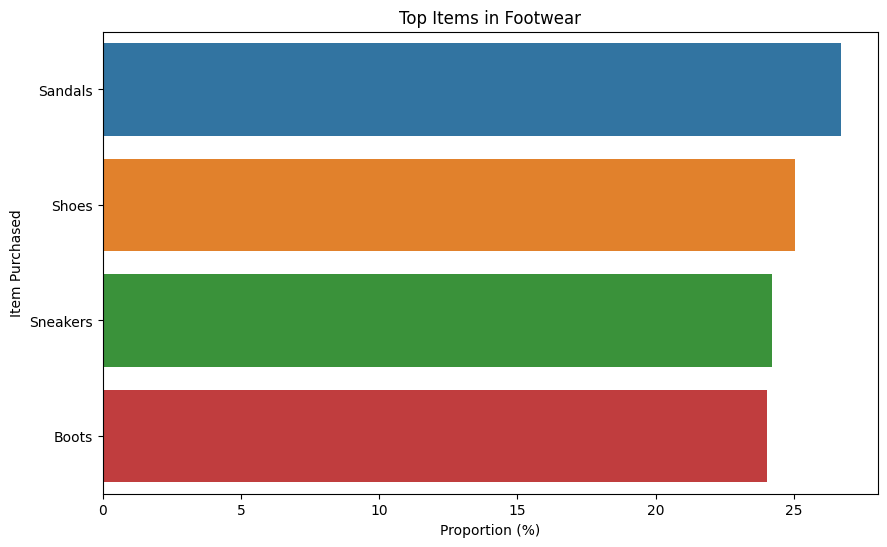

### Q8: Display the top items in Outerwear category in a bar chart

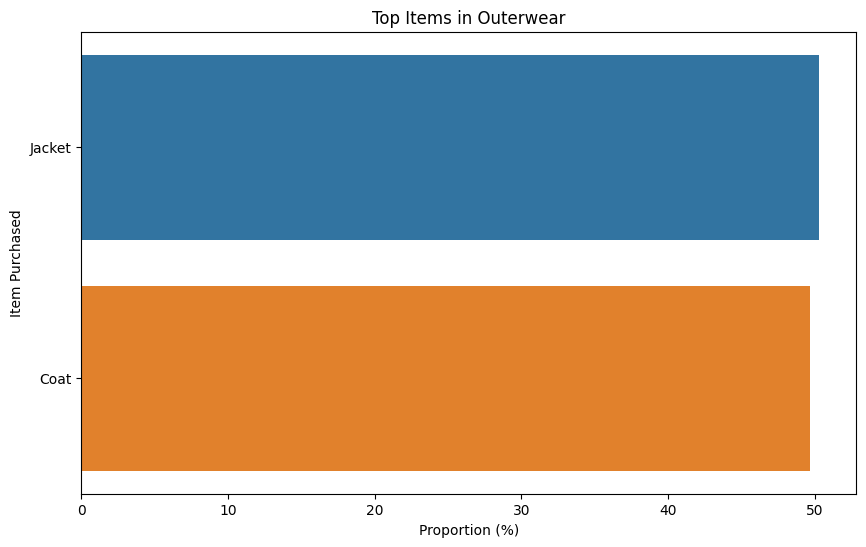

In [20]:
item_by_category=(df.groupby('Category')['Item Purchased'].value_counts(normalize=True)*100).reset_index()
item_by_category
categories = item_by_category['Category'].unique()
for cat in categories:
    plt.figure(figsize=(10,6))
    data = item_by_category[item_by_category['Category']==cat]
    sns.barplot(data=data, y='Item Purchased', x='proportion',hue='Item Purchased')
    plt.title(f'Top Items in {cat}')
    plt.xlabel('Proportion (%)')
    plt.ylabel('Item Purchased')
    display(Markdown(f"### Q8: Display the top items in {cat} category in a bar chart"))
    plt.show()

## **Q9: Shipping Analysis**

### Display the shipping type distribution in a bar chart

**Insight:**  
- Shows the frequency of each shipping type chosen by customers.  
- Helps identify **preferred shipping options** such as Free Shipping, Standard, or Express.  
- Useful for improving logistics, planning promotions, and enhancing customer satisfaction.


### Q9: Display the shipping type distribution in a bar chart

Text(0, 0.5, 'Number of Occurrences')

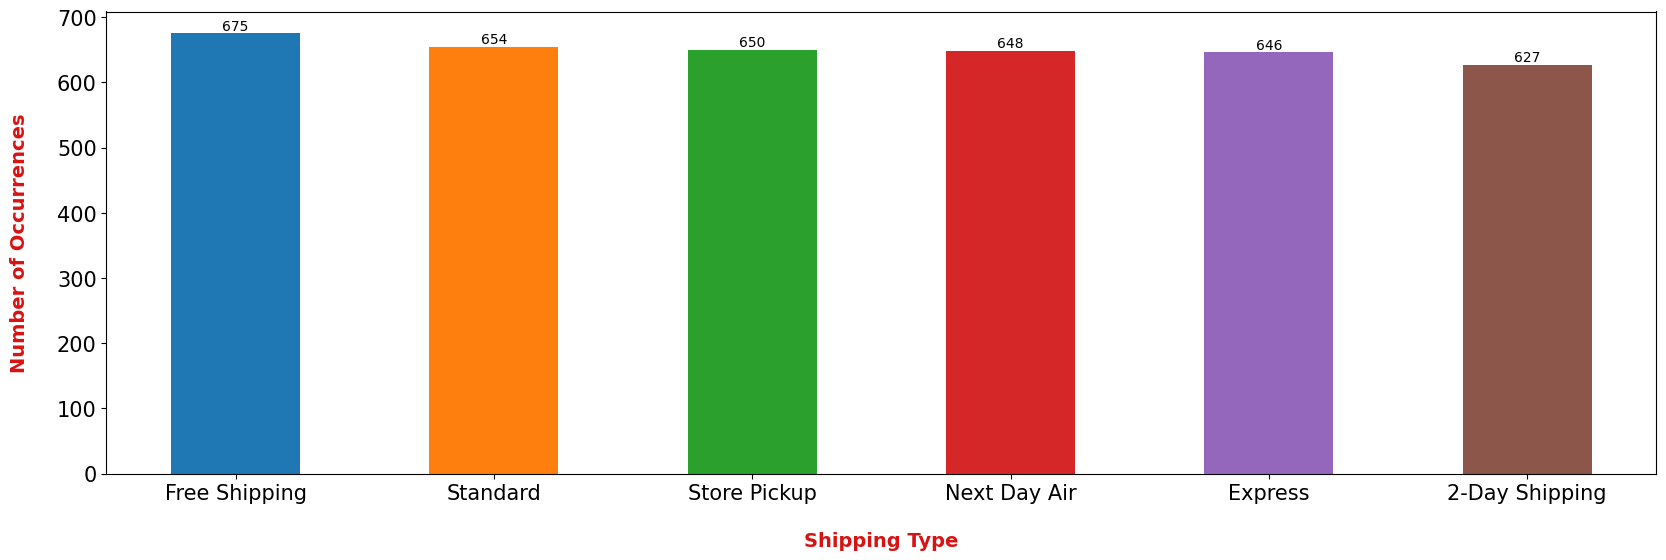

In [21]:
plt.figure(figsize = (20, 6))
ax = df["Shipping Type"].value_counts().plot(kind = 'bar', color = colors, rot = 0)
ax.set_xticklabels(('Free Shipping', 'Standard', 'Store Pickup', 'Next Day Air', 'Express', '2-Day Shipping'))
display(Markdown("### Q9: Display the shipping type distribution in a bar chart"))
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + 0.25, p.get_height() + 1), ha = 'center', va = 'bottom', color = 'black')
    ax.tick_params(axis = 'both', labelsize = 15)
plt.xlabel('Shipping Type', weight = "bold", color = "#D71313", fontsize = 14, labelpad = 20)
plt.ylabel('Number of Occurrences', weight = "bold", color = "#D71313", fontsize = 14, labelpad = 20)


## **Q10: Discounts & Promotions**

### Q10.a: Display items purchased by discount applied in a bar chart

**Insight:**  
- Shows how different discount levels affect the popularity of items purchased.  
- Highlights which items sell more when specific discounts are applied.  
- Useful for **promotion planning** and understanding the **effectiveness of discount campaigns**.


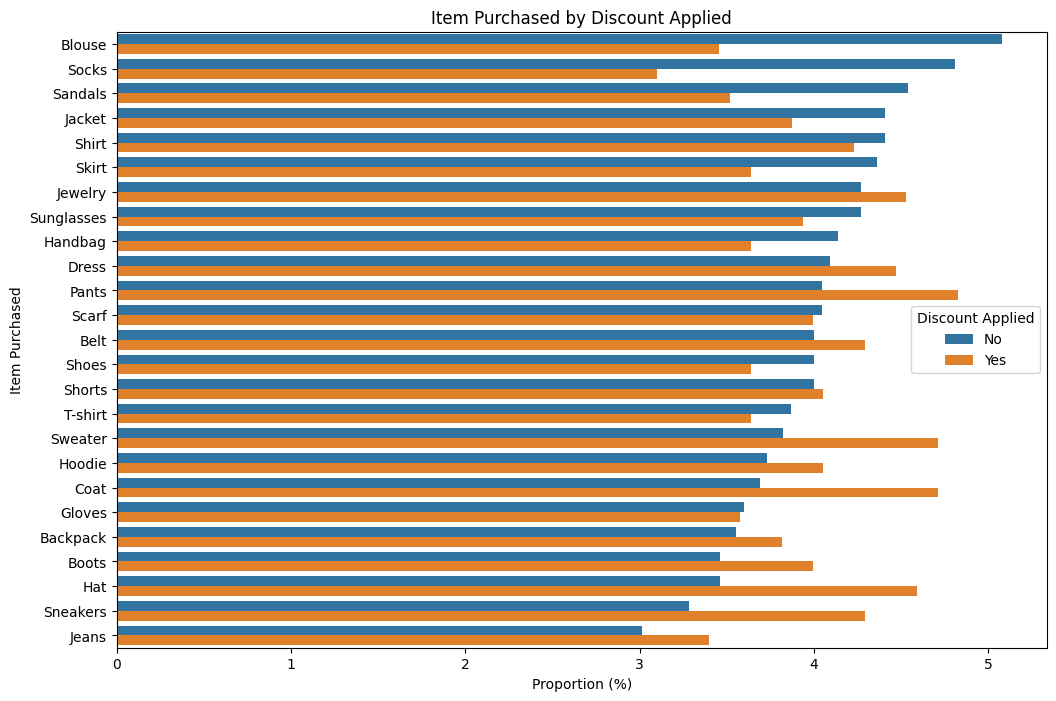

In [22]:
df_discount=(df.groupby('Discount Applied')['Item Purchased'].value_counts(normalize=True)*100).reset_index()
df_discount
plt.figure(figsize=(12,8))
sns.barplot(data=df_discount,x='proportion',y='Item Purchased',hue='Discount Applied',dodge=True)
plt.title('Item Purchased by Discount Applied')
plt.xlabel('Proportion (%)')
plt.ylabel('Item Purchased')
plt.legend(title='Discount Applied')
plt.show()


### Q10.b: Display items purchased by promo code used in a bar chart

**Insight:**  
- Shows how the usage of promo codes influences item purchases.  
- Highlights which items are more likely to be bought when promo codes are applied.  
- Useful for evaluating the **effectiveness of promotional campaigns** and planning future marketing strategies.


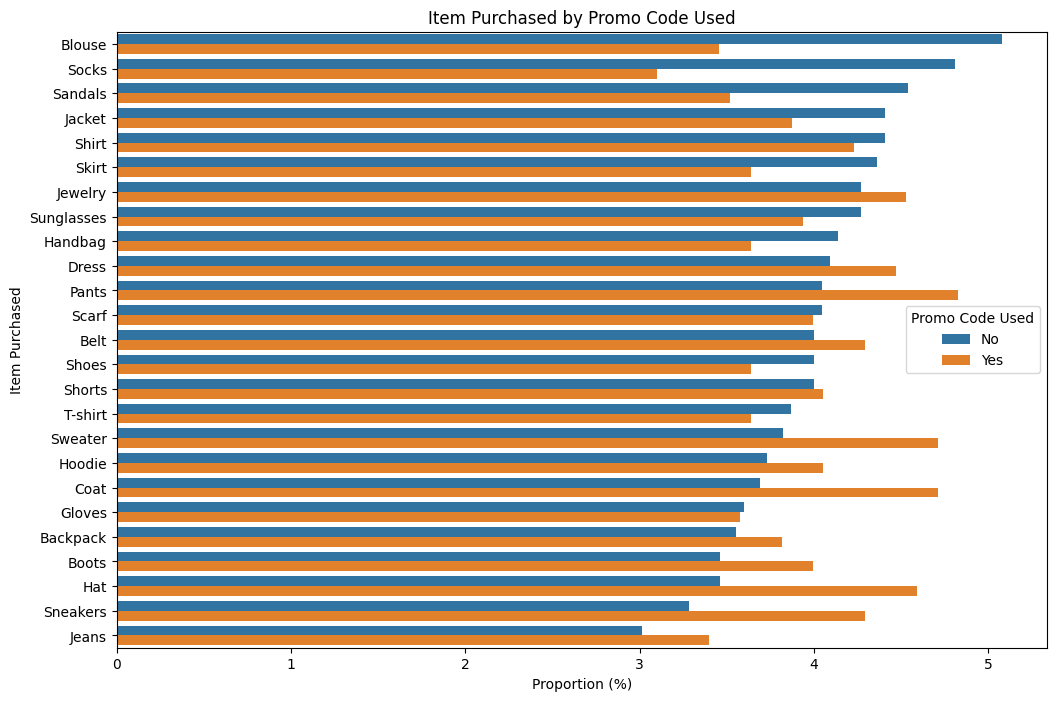

In [23]:
df_discount_code=(df.groupby('Promo Code Used')['Item Purchased'].value_counts(normalize=True)*100).reset_index()
df_discount_code
plt.figure(figsize=(12,8))
sns.barplot(data=df_discount_code,x='proportion',y='Item Purchased',hue='Promo Code Used',dodge=True)
plt.title('Item Purchased by Promo Code Used')
plt.xlabel('Proportion (%)')
plt.ylabel('Item Purchased')
plt.legend(title='Promo Code Used')
plt.show()

📌 **Overall Summary**

The Shopping Trends Dataset reveals that **demographics, seasonality, payment/shipping preferences, and promotions** drive purchasing behavior. **Clothing and Accessories** are the most popular categories, with spending peaking in specific seasons. Discounts and promo codes boost sales, guiding **targeted marketing, inventory planning, and data-driven business decisions**.


| **Aspect**                | **Purpose**                   | **Key Findings / Insights**                                 |
|---------------------------|-------------------------------|-------------------------------------------------------------|
| **Data Cleaning**         | Ensure reliability            | Dataset cleaned, no major missing or duplicate issues       |
| **Demographics**          | Understand customers          | Gender and age affect shopping patterns                     |
| **Numerical Trends**      | Analyze spending patterns     | Skewed purchase amounts with distinct seasonal peaks        |
| **Seasonal Analysis**     | Find peak shopping periods    | Clear increase during festive or sale seasons              |
| **Payment Methods**       | Identify customer preferences | Credit/Debit cards dominate, followed by digital wallets   |
| **Product Insights**      | Discover top-selling items    | Clothing and accessories lead sales                         |
| **Shipping & Promotions** | Evaluate delivery and offers  | Free and standard shipping preferred; discounts drive sales |


## **Overall Insights**

- Customer purchases are influenced by **demographics, seasonal trends, payment methods, shipping preferences, and promotions**.  
- **Clothing** and **Accessories** are the most popular categories, driving the majority of sales.  
- Purchase amounts peak during specific seasons, highlighting **high-traffic periods** for marketing campaigns.  
- Discounts and promo codes significantly increase item sales, demonstrating the **effectiveness of promotions**.  
- Payment and shipping preferences vary by age and customer segment, providing opportunities for **personalized offers and improved service**.  
- These insights can guide **targeted marketing, inventory planning, and enhanced customer engagement**, supporting **data-driven business decisions**.


---

### 🧑‍💻 **Project Done By**

| **Name**              | **Roll No.** | **Department**             | **Semester** |
|------------------------|--------------|-----------------------------|---------------|
| Siri Chandana Gudeti   | 160124771010 | Artificial Intelligence & Data Science | 3rd Semester |
| Holkundi Thrisha       | 160124771012 | Artificial Intelligence & Data Science | 3rd Semester |

---
